# **05 : 종합실습**
* CIFAR-10 데이터 세트
    * AlexNet의 창시자 Alex krizhevsky가 수집하여 만든 데이터 셋
    * 10개 클래스에 32x32 컬러 이미지 60000개로 구성되어 있으며, 클래스당 6000개 이미지가 있습니다. 50000개의 훈련 이미지와 10000개의 테스트 이미지가 있음
* 모델 평가 : accuracy score
    * 지금까지 배운 내용을 총 동원해서 accuracy를 높여 보자

![](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)


## 1.환경준비

### (1) 라이브러리 Import

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [171]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 학습을 위한 함수

In [172]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [173]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [174]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [175]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터 셋

#### 1) 다운로드

In [176]:
train_dataset = datasets.CIFAR10(root="./", train=True, download=True, transform=ToTensor())
test_dataset = datasets.CIFAR10(root="./", train=False, download=True, transform=ToTensor())

#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [177]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

* dataset.data : 구조가 이전과 다르다.
    * 파이토치가 받아들이는 구조 : (50000, 3, 32, 32)
    * 제공되는 구조 : (50000, 32, 32, 3)
        * data loader를 이용하면 자동으로 변환해줌 : (n, 3, 32, 32)

In [178]:
train_dataset.data.shape

(50000, 32, 32, 3)

* train_dataset.targets : 리스트

In [179]:
train_dataset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

* y(target)의 클래스

In [180]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

* 데이터 1건

In [181]:
train_dataset[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

* 데이터 이미지 확인

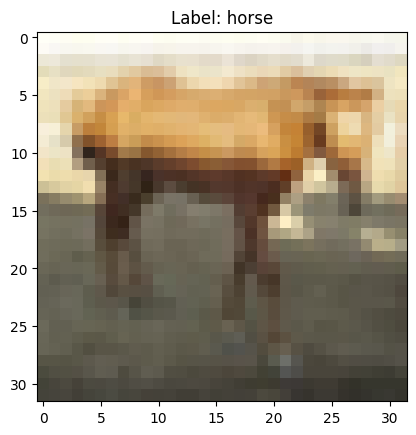

In [182]:
n = 2000
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image)
plt.title(f"Label: {train_dataset.classes[label]}")
plt.show()

- 랜덤으로 32개 이미지 확인

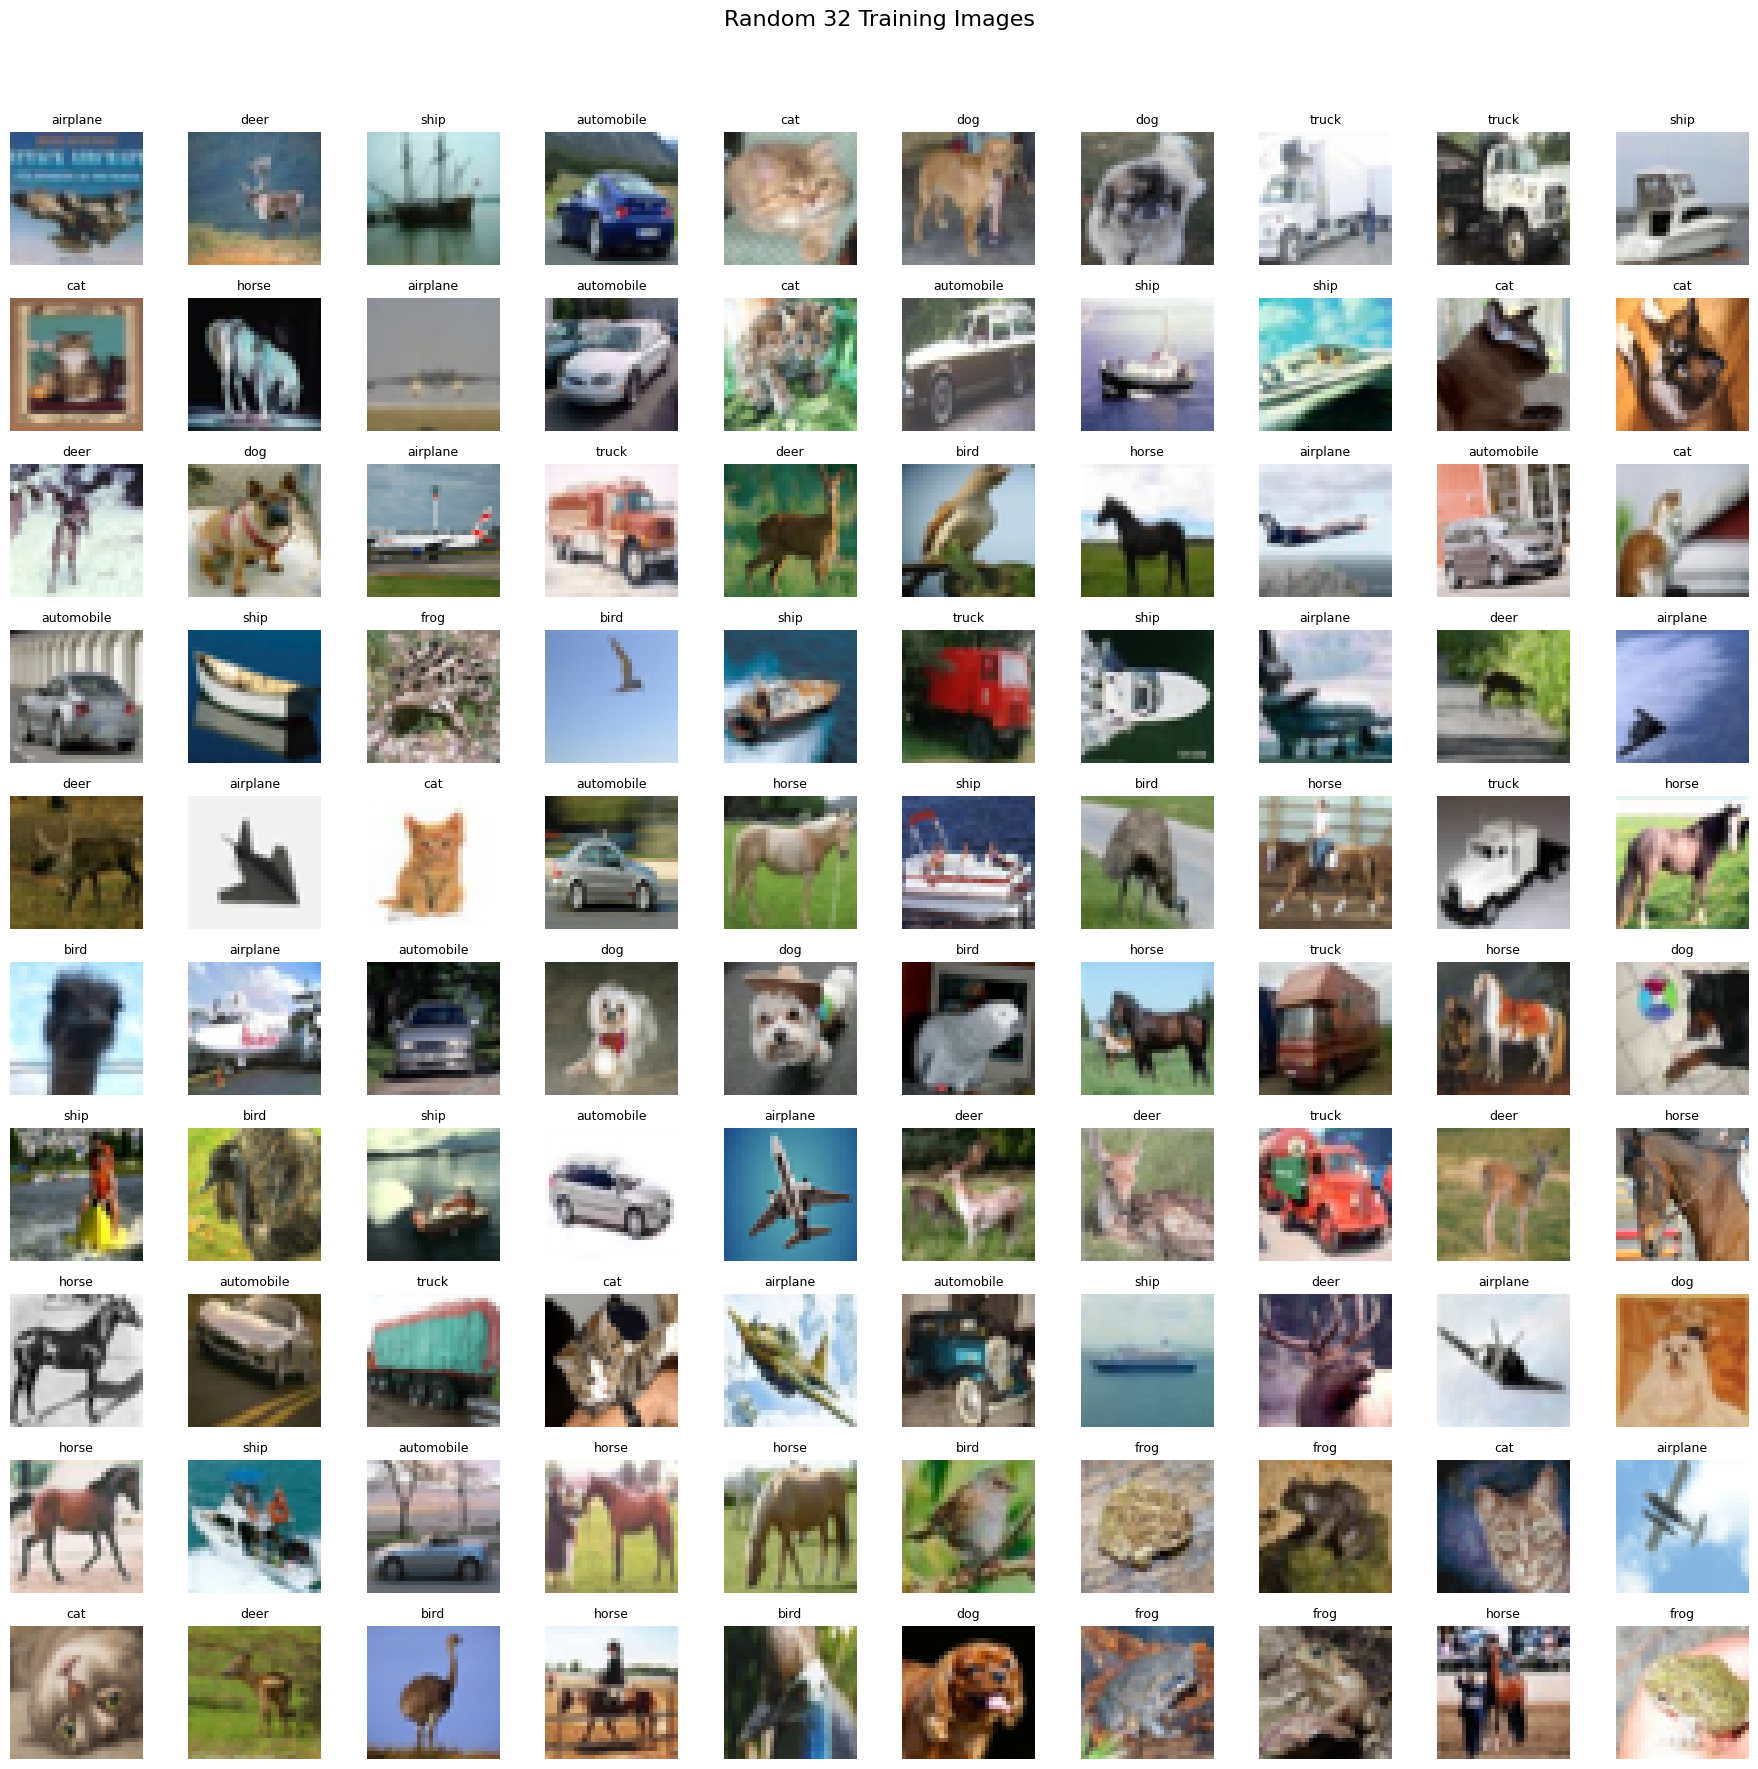

In [183]:
import matplotlib.pyplot as plt
import torch

# 100개의 랜덤한 인덱스 선택
num_images = 100
random_indices = torch.randint(0, len(train_dataset), (num_images,))

# 서브플롯 생성 (10×10)
fig, axes = plt.subplots(10, 10, figsize=(18, 18))
fig.suptitle("Random 32 Training Images", fontsize=16)

# 랜덤 샘플링하여 이미지 출력
for i, ax in enumerate(axes.flat):
    index = random_indices[i].item()  # 랜덤 인덱스 가져오기
    image, label = train_dataset.data[index], train_dataset.targets[index]

    ax.imshow(image, cmap="gray")  # 흑백 이미지 출력
    ax.set_title(f"{train_dataset.classes[label]}", fontsize=9)
    ax.axis("off")  # 축 제거

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 2.데이터 준비

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [184]:
# 배치 사이즈를 지정해서 Data Loader로 선언하기
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [185]:
# 첫번째 배치만 로딩해서 살펴보기
for temp_X, temp_y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {temp_X.shape}")
    print(f"Shape of y: {temp_y.shape} {temp_y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


데이터 로더를 통과한 데이터의 결과를 보면 [64, 3, 32, 32]

### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옴
    * 스케일링 안된 데이터
    * **5000, 28, 28, 3** : 채널 차원이 뒤에 나옴.
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함.
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨.
    * 차원 위치 변환 : **5000, 3, 28, 28**

In [188]:
# 1) 데이터와 레이블 추출
test_data = test_dataset.data  # x : (10000, 32, 32, 3)
test_targets = np.array(test_dataset.targets) # y

# 2) 데이터 위치 조정 : [n(0), 세로픽셀(1), 가로픽셀(2), 채널(3)] -> [n(0), 채널(3), 세로픽셀(1), 가로픽셀(2)]
test_data = test_data.transpose((0, 3, 1, 2))  # (10000, 3, 32, 32)

# 데이터 샘플링, 층화추출
x_val, x_test, y_val, y_test = train_test_split(
    test_data,
    test_targets,
    test_size=5000,
    random_state=10,
    stratify=test_targets
)

# tensor로 변환
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)


In [189]:
# x_val, y_val, x_test, y_test의 shape 확인
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_val shape: torch.Size([5000, 3, 32, 32])
y_val shape: torch.Size([5000])
x_test shape: torch.Size([5000, 3, 32, 32])
y_test shape: torch.Size([5000])


* 스케일링

In [190]:
# 스케일링: 원본데이터가 0~255까지 숫자이므로, 255로 나눠주면 됨.
x_val = x_val / 255.0
x_test = x_test / 255.0

In [191]:
# 함수 정리
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""

    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

## 3.모델링1

### (1) 모델 선언

In [192]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(3, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 2 * 2, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 32, 32]             112
              ReLU-2            [-1, 4, 32, 32]               0
         MaxPool2d-3            [-1, 4, 16, 16]               0
            Conv2d-4            [-1, 8, 16, 16]             296
              ReLU-5            [-1, 8, 16, 16]               0
         MaxPool2d-6              [-1, 8, 8, 8]               0
            Conv2d-7             [-1, 32, 8, 8]           2,336
              ReLU-8             [-1, 32, 8, 8]               0
         MaxPool2d-9             [-1, 32, 4, 4]               0
           Conv2d-10             [-1, 64, 4, 4]          18,496
             ReLU-11             [-1, 64, 4, 4]               0
        MaxPool2d-12             [-1, 64, 2, 2]               0
          Flatten-13                  [-1, 256]               0
           Linear-14                   

### (2) 학습

Epoch 1, train loss : 1.0586, val loss : 1.1343, val acc : 0.6038
Epoch 2, train loss : 1.0303, val loss : 1.1248, val acc : 0.6040
Epoch 3, train loss : 1.0131, val loss : 1.1124, val acc : 0.6090
Epoch 4, train loss : 0.9907, val loss : 1.1150, val acc : 0.6000
===> early stopping, best_loss : 1.1124, counter : 1
Epoch 5, train loss : 0.9740, val loss : 1.0845, val acc : 0.6148
Epoch 6, train loss : 0.9548, val loss : 1.1084, val acc : 0.6080
===> early stopping, best_loss : 1.0845, counter : 1
Epoch 7, train loss : 0.9418, val loss : 1.0924, val acc : 0.6140
===> early stopping, best_loss : 1.0845, counter : 2
Epoch 8, train loss : 0.9260, val loss : 1.0756, val acc : 0.6216
Epoch 9, train loss : 0.9128, val loss : 1.1157, val acc : 0.6074
===> early stopping, best_loss : 1.0756, counter : 1
Epoch 10, train loss : 0.8947, val loss : 1.0726, val acc : 0.6290
Epoch 11, train loss : 0.8814, val loss : 1.1135, val acc : 0.6186
===> early stopping, best_loss : 1.0726, counter : 1
Epoch 1

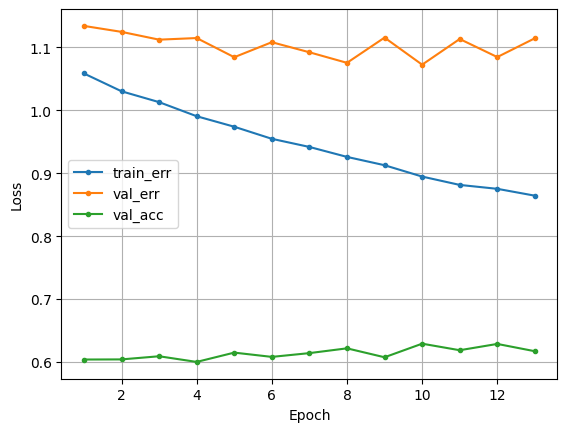

In [194]:
epochs = 1000
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정
patience = 3
best_loss = float("inf")            # 초기값을 무한대로 설정
counter = 0
# -----------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")
    # early stopping 확인-----------------------------------------------
    if val_loss > best_loss:
        counter += 1
        print(f"===> early stopping, best_loss : {best_loss:.4f}, counter : {counter}")
    else:
        best_loss = val_loss
        counter = 0

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!!")
        break
    # -----------------------------------------------------------------
# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

## 4.모델링2

### (1) 모델 선언

### (2) 학습

### (3) 모델 평가